# Jupyter notebook: Xử lý ảnh biển số và nhận diện OCR

Notebook này hướng dẫn các bước xử lý ảnh biển số xe và nhận diện ký tự bằng OCR (pytesseract).

In [1]:
# 1. Import Required Libraries
import cv2
import matplotlib.pyplot as plt

In [ ]:
# 4b. Apply OCR using PaddleOCRWrapper
from VehicleDetectionTracker.function.paddleocr_wrapper import PaddleOCRWrapper

# Khởi tạo PaddleOCRWrapper
ocr_wrapper = PaddleOCRWrapper(lang='en', use_angle_cls=True)

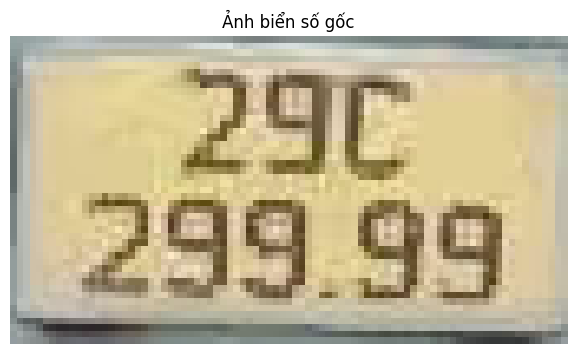

In [88]:
# 2. Load and Display License Plate Image
# Đường dẫn ảnh biển số (thay bằng ảnh của bạn)
# image_path = r'D:\TrucNV\vehicle_detection_tracker\screenshots\20260121\154128_2\license_frame_20260121_154128_806.png'
image_path = r"D:\TrucNV\vehicle_detection_tracker\screenshots\20260121\140043_2071\license_frame_20260121_140043_392.png"
img = cv2.imread(image_path)
# img = img[3:-3,3:-3,:]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,4))
plt.imshow(img_rgb)
plt.title('Ảnh biển số gốc')
plt.axis('off')
plt.show()

In [90]:
results = ocr_wrapper.ocr.predict(img_rgb)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 299.99 0.9996330142021179
text, confidence: 322 0.4087059199810028


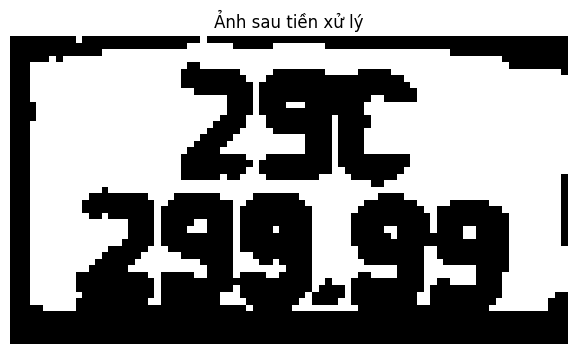

In [96]:
# 3. Preprocess Image for OCR
# Chuyển sang ảnh xám, tăng tương phản, lọc nhiễu, threshold
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)
img_eq = cv2.equalizeHist(img_blur)
_, img_thresh = cv2.threshold(img_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(8,4))
plt.imshow(img_thresh, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [97]:
results = ocr_wrapper.ocr.predict(img_thresh)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

IndexError: tuple index out of range

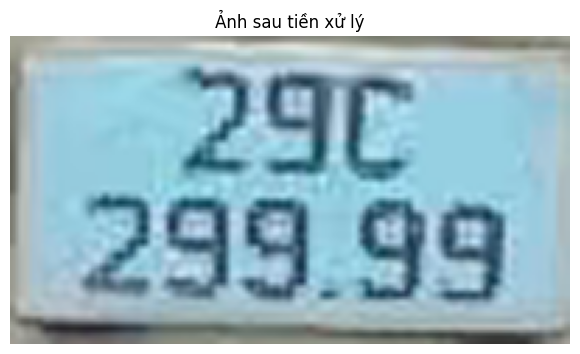

In [81]:
img_array = img
# 2. Resize ảnh để tăng độ phân giải
height, width = img_array.shape[:2]
if height < 100 or width < 200:
    scale_factor = max(200 / width, 100 / height)
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)
    resized = cv2.resize(
        img_array, (new_width, new_height), interpolation=cv2.INTER_CUBIC
    )

plt.figure(figsize=(8,4))
plt.imshow(resized, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [98]:
results = ocr_wrapper.ocr.predict(resized)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 299.99 0.9996321201324463
text, confidence: 222 0.538260817527771


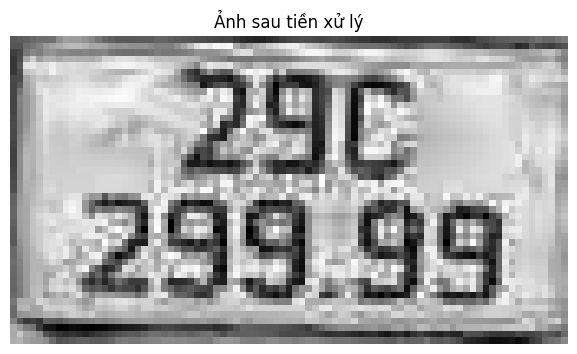

In [82]:

# 3. Chuyển sang grayscale
if len(img_array.shape) == 3:
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
else:
    gray = img_array.copy()

# 4. Tăng contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

plt.figure(figsize=(8,4))
plt.imshow(enhanced, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [99]:
results = ocr_wrapper.ocr.predict(enhanced)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

IndexError: tuple index out of range

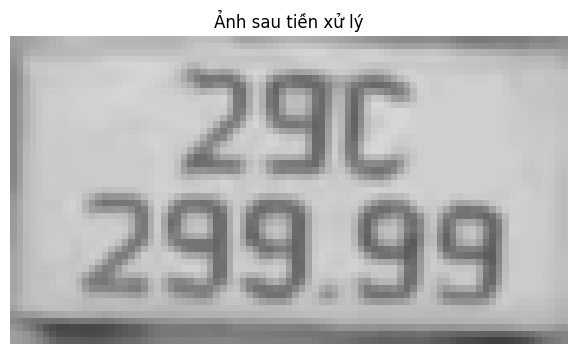

In [83]:

# 5. Gaussian blur để làm mịn
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
img = cv2.cvtColor(blurred, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(8,4))
plt.imshow(img, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [101]:
results = ocr_wrapper.ocr.predict(img)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 26667 0.7724310159683228
text, confidence: 22Z 0.4632146656513214


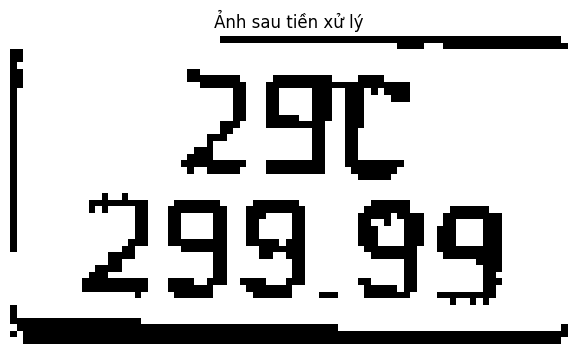

In [115]:

# 6. Threshold binary
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
img = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(8,4))
plt.imshow(img, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [102]:
results = ocr_wrapper.ocr.predict(img)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 26667 0.7724310159683228
text, confidence: 22Z 0.4632146656513214


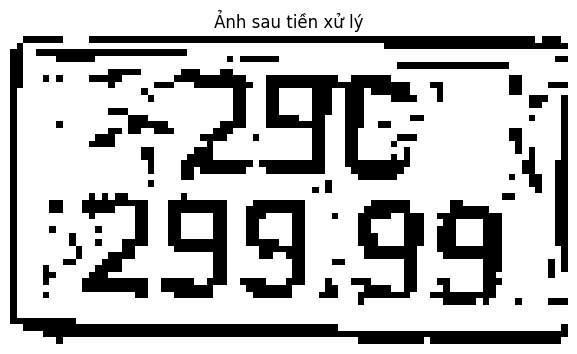

In [85]:

# 7. Adaptive threshold
adaptive = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)
img = cv2.cvtColor(adaptive, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(8,4))
plt.imshow(img, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [103]:
results = ocr_wrapper.ocr.predict(img)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 26667 0.7724310159683228
text, confidence: 22Z 0.4632146656513214


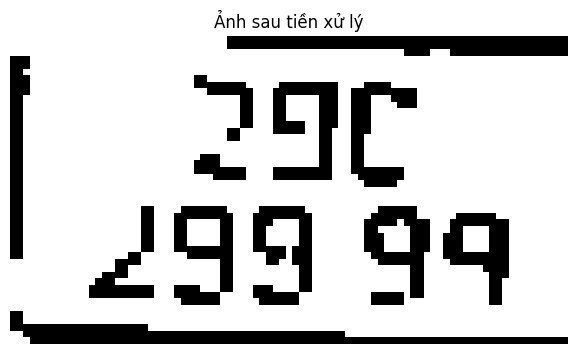

In [111]:

# 8. Morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,  2))
morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
img = cv2.cvtColor(morph, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(8,4))
plt.imshow(img, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [ ]:
adaptive = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# 8. Morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,  2))
morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
img = cv2.cvtColor(morph, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(8,4))
plt.imshow(img, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [104]:
results = ocr_wrapper.ocr.predict(img)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 26667 0.7724310159683228
text, confidence: 22Z 0.4632146656513214


Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


[2026-01-21 15:53:27] ✓ PaddleOCR: PaddlePaddle được compile cho CPU, sử dụng CPU


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


[2026-01-21 15:53:29] OK: PaddleOCR initialized successfully (lang=en, device=CPU)


In [87]:
results = ocr_wrapper.ocr.predict(img)

if results and len(results) > 0:
    # Xử lý kết quả - phiên bản mới có cấu trúc khác
    result = results[0] if isinstance(results, list) else results

    # Cấu trúc mới: dict với rec_texts và rec_scores
    if "rec_texts" in result and "rec_scores" in result:
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, confidence in zip(texts, scores):
            print("text, confidence:", text, confidence)

text, confidence: 66 667 0.9844735264778137
text, confidence: 3GZ 0.643146276473999


In [1]:
print("P --- IGNORE ---")

P --- IGNORE ---


In [2]:
import re

normalized = ['166.34', '77C', '16534', '-165344', '77C3']

In [4]:
province_part = next(
    (t for t in normalized if re.match(r"^\d{2,3}[A-Z]{1,2}$", t.upper())), ""
)
print(province_part)

77C


In [5]:
import os
print(os.cpu_count())

20
